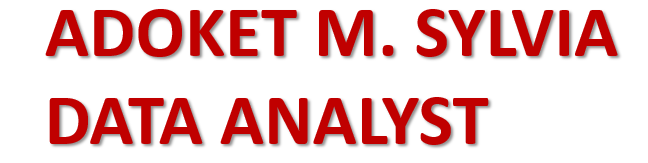

# **HYPOTHESIS TESTING**

In [4]:
#!pip install pingouin


   -------------------- ------------------- 1/2 [pingouin]
   ---------------------------------------- 2/2 [pingouin]



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import pingouin as pg
from scipy.stats import shapiro

### **Load the Dataset**

In [9]:
gss = pd.read_csv("GSSsubset.csv")
gss.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


# **One Sample T-test**  

In [10]:
age_data = gss['age'].dropna()

test_value = 30
one_sample_test = pg.ttest(age_data, test_value)
one_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,34.799147,993,two-sided,4.127386e-174,"[43.67, 45.31]",1.103762,1.0,1.284e+170


In [11]:
income_data = gss['income'].dropna()

test_value = 25000
one_sample_test = pg.ttest(income_data, test_value)
one_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,10.7998,993,two-sided,8.752187e-26,"[34727.28, 39047.16]",0.342549,1.0,2.71e+22


In [12]:
height_data = gss['height'].dropna()

test_value = 65
one_sample_test = pg.ttest(height_data, test_value)
one_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,18.852961,993,two-sided,5.206185e-68,"[67.16, 67.67]",0.59798,1.0,2.298e+64


In [13]:
weight_data = gss['weight'].dropna()

test_value = 150
one_sample_test = pg.ttest(weight_data, test_value)
one_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,23.712226,993,two-sided,7.538648e-99,"[178.73, 183.91]",0.752106,1.0,1.173e+95


## **Two-Sample t-test**

## Independent Two-Sample t-test (Gender by Age)

In [14]:
# There is no significant difference on average age between group A and B
# There is significant difference on average age between group A and B


group_A = gss[gss['sex'] == 'MALE']['age'].dropna()
group_B = gss[gss['sex'] == 'FEMALE']['age'].dropna()

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,0.952437,989.144792,two-sided,0.341108,"[-0.84, 2.43]",0.060448,0.158478,0.111


## Gender by Height

In [15]:
# There is no significant difference on average height between group A and B
# There is significant difference on average height between group A and B

group_A = gss[gss['sex'] == 'MALE']['height'].dropna()
group_B = gss[gss['sex'] == 'FEMALE']['height'].dropna()

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,28.783788,991.39046,two-sided,6.436429e-133,"[5.07, 5.81]",1.823912,1.0,7.741e+128


## **Paired t-test**

Ho: There is no significant difference on average test scores before and after interventions
H1: There is significant difference on average test scores before and after the interventions

In [16]:
from scipy import stats

before = [72, 75, 78, 71, 69, 74, 77, 73, 76, 70]
after = [75, 78, 80, 74, 72, 77, 79, 75, 78, 73]

# Perform paired t-test
t_statistic, p_value = stats.ttest_rel(before, after)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: there is a significant difference between the paired samples.")

t-statistic: -15.921683328090657
p-value: 6.713856195677205e-08
Reject the null hypothesis: there is a significant difference between the paired samples.


## **Alternatively**

In [17]:
pg.ttest(before, after, paired = True)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-15.921683,9,two-sided,6.713856e-08,"[-2.97, -2.23]",0.908575,0.725205,1.65e+05


## **Chi-Square Test for Independence**

### Ho: The two variables are independent
### H1: The two variables are dependent

In [18]:
contingency_table = pd.crosstab(gss["sex"], gss["marital"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test Result (Gender vs Marital Status):")
print("Chi2:", chi2, "p-value:", p, "Degrees of Freedom:", dof)
print("p-value:", p)
print("Degrees of Freedom:", dof)

alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: there is a significant association between the variables.")
else:
    print("Fail to reject the null hypothesis: no significant association between the variables.")

Chi-Square Test Result (Gender vs Marital Status):
Chi2: 6.211308199614711 p-value: 0.18391363117203863 Degrees of Freedom: 4
p-value: 0.18391363117203863
Degrees of Freedom: 4
Fail to reject the null hypothesis: no significant association between the variables.


# **Independence between Sex and Marital**

In [19]:
expected, observed, stats = pg.chi2_independence(data=gss, x='sex', y='marital')

In [20]:
observed

marital,DIVORCED,MARRIED,NEVER MARRIED,SEPARATED,WIDOWED
sex,,,,,
FEMALE,85,220,140,19,23
MALE,87,260,129,18,13


In [21]:
expected

marital,DIVORCED,MARRIED,NEVER MARRIED,SEPARATED,WIDOWED
sex,,,,,
FEMALE,84.269618,235.171026,131.793763,18.127767,17.637827
MALE,87.730382,244.828974,137.206237,18.872233,18.362173


In [22]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,6.211308,4.0,0.183914,0.079049,0.485258
1,cressie-read,0.666667,6.218386,4.0,0.183422,0.079094,0.485763
2,log-likelihood,0.000000,6.249637,4.0,0.181265,0.079293,0.487987
3,freeman-tukey,-0.500000,6.288514,4.0,0.178613,0.079539,0.490748
4,mod-log-likelihood,-1.000000,6.341226,4.0,0.175073,0.079872,0.494482
5,neyman,-2.000000,6.491066,4.0,0.165354,0.080810,0.505024


## **Chi-Square between Degree and Marital Status**

### Ho: There is no an association between Degree and Marital Status
### H1: There is an association betweeb Degree and Marital Status

In [23]:
from scipy import stats
contingency_table = pd.crosstab(gss["degree"], gss["marital"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test Result (degree vs marital Status):")
print("Chi2:", chi2, "p-value:", p, "Degrees of Freedom:", dof)
print("p-value:", p)
print("Degrees of Freedom:", dof)

alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: there is a significant association between the variables.")
else:
    print("Fail to reject the null hypothesis: no significant association between the variables.")

Chi-Square Test Result (degree vs marital Status):
Chi2: 41.21704406686576 p-value: 0.0005157532586077217 Degrees of Freedom: 16
p-value: 0.0005157532586077217
Degrees of Freedom: 16
Reject the null hypothesis: there is a significant association between the variables.


In [24]:
chi2

np.float64(41.21704406686576)

In [25]:
expected

array([[ 36.16498994, 100.92555332,  56.56036217,   7.77967807,
          7.5694165 ],
       [ 21.62977867,  60.36217304,  33.82796781,   4.65291751,
          4.52716298],
       [ 84.96177062, 237.10261569, 132.87625755,  18.27665996,
         17.78269618],
       [ 15.9195171 ,  44.42655936,  24.89738431,   3.42454728,
          3.33199195],
       [ 13.32394366,  37.18309859,  20.83802817,   2.86619718,
          2.78873239]])

## **HOMEWORK**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import pingouin as pg
from scipy.stats import shapiro

In [5]:
customer = pd.read_csv("customerData.csv")
customer.head()

,customer_id,age,gender,income,monthly_spend,occupation,payment_type,city,education_level,satisfaction_score
0,1,56,Female,59148.54,24524.79,Business,Card,Nakuru,Masters,6
1,2,46,Female,45239.30,23544.97,Teacher,Bank Transfer,Mombasa,PhD,1
2,3,32,Female,71096.31,15464.20,Business,Mobile Money,Kisumu,Undergraduate,7
3,4,60,Female,52540.59,22059.59,Healthcare,Mobile Money,Nairobi,Masters,6
4,5,25,Male,63208.24,14784.25,IT,Bank Transfer,Kisumu,Masters,4


# One-Sample t-test

### Ho: There is no significant difference on the average mean on age
### H1: There is significant difference on the average mean on age

In [6]:
age_data = customer['age'].dropna()

test_value = 45
one_sample_test = pg.ttest(age_data, test_value)
one_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-9.887936,1199,two-sided,3.235499e-22,"[40.37, 41.9]",0.28544,1.0,7.474e+18


**Since p-value of 3.235499e-22 is much less than 0.05,we reject the null hypothesis.Hence, there is statistically significant evidence that the mean age is different from 45.
The sample data provides very strong evidence that the true population mean age is significantly different from 45 years. The 95% confidence interval [40.37, 41.9] indicates the actual mean age is likely between approximately 40.4 and 41.9 years, which is notably lower than the tested value of 45. The large Bayes Factor (7.474e+18) and Cohen's d of 0.285 suggest this is both a statistically significant and practically meaningful difference.**


# Two-Sample t-test

#### Ho:There is no significant difference on the average mean between group A and group B
#### H1: There is significant difference on the average mean between group A and group B

In [7]:

group_A = customer[customer['gender'] == 'Male']['age'].dropna()
group_B = customer[customer['gender'] == 'Female']['age'].dropna()

two_sample_test = pg.ttest(group_A, group_B, paired=False)
two_sample_test

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-0.306302,1190.884065,two-sided,0.759428,"[-1.77, 1.3]",0.017691,0.060806,0.068


**Since p-value = 0.759428 > 0.05,we fail to reject null hypothesis.Hence,
 There is insufficient evidence to conclude that there is a statistically significant difference in mean age between males and females at the 0.05 significance level.The observed difference in ages between the two groups could reasonably be due to random sampling variation.**


# Chi-Square Test

#### Ho:There is no an association between two categorical variables
#### H1:There is  an association between two categorical variables

In [10]:
import pandas as pd
from scipy import stats

# Create a Contingency Table (age vs city)
contingency_table = pd.crosstab(customer["age"], customer["city"])

# perform chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test Result (age vs city):")
print("Chi2:", chi2, "p-value:", p, "Degrees of Freedom:", dof)
print("p-value:", p)
print("Degrees of Freedom:", dof)

# Interpret the result
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: there is a significant association between the variables.")
else:
    print("Fail to reject the null hypothesis: no significant association between the variables.")

Chi-Square Test Result (age vs city):
Chi2: 181.99490218628512 p-value: 0.5279477322807324 Degrees of Freedom: 184
p-value: 0.5279477322807324
Degrees of Freedom: 184
Fail to reject the null hypothesis: no significant association between the variables.


**Since the p-value (0.528) is greater than the significance level (α = 0.05), we fail to reject the null hypothesis.
Therefore,no statistically significant association between age and city in this dataset.The relatively high p-value (52.8%) suggests the data provides strong evidence that age and city are independent variables in this customer dataset.**

# **Alternatively**

In [38]:
import warnings
warnings.filterwarnings('ignore')
expected, observed, stats = pg.chi2_independence(data=customer, x='occupation', y='income')

In [40]:
observed

income,2928.55,11675.93,12512.21,13396.56,15417.87,16624.47,17114.22,18703.82,18851.68,18958.69,...,89929.29,89998.67,90012.45,91221.86,91973.16,94513.33,94947.74,95171.65,95313.02,95963.01
occupation,,,,,,,,,,,,,,,,,,,,,
Business,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
Engineer,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Government,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Healthcare,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
IT,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
Student,0,1,0,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
Teacher,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [41]:
expected

income,2928.55,11675.93,12512.21,13396.56,15417.87,16624.47,17114.22,18703.82,18851.68,18958.69,...,89929.29,89998.67,90012.45,91221.86,91973.16,94513.33,94947.74,95171.65,95313.02,95963.01
occupation,,,,,,,,,,,,,,,,,,,,,
Business,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,...,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448,0.128448
Engineer,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,...,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966,0.168966
Government,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,...,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966,0.143966
Healthcare,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,...,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828,0.144828
IT,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,...,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793,0.138793
Student,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,...,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414,0.147414
Teacher,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,...,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586,0.127586


In [42]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,6960.000000,6954.0,0.477466,0.983192,1.000000
1,cressie-read,0.666667,5545.912931,6954.0,1.000000,0.877648,1.000000
2,log-likelihood,0.000000,4505.231908,6954.0,1.000000,0.791029,0.999994
3,freeman-tukey,-0.500000,NaN,6954.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,6954.0,0.000000,inf,NaN
5,neyman,-2.000000,NaN,6954.0,NaN,NaN,NaN


**We reject the null hypothesis (H₀: occupation and income are independent).There is a statistically significant association between occupation and income level.**

In [43]:
import warnings
warnings.filterwarnings('ignore')
expected, observed, stats = pg.chi2_independence(data=customer, x='gender', y='income')

In [44]:
observed

income,2928.55,11675.93,12512.21,13396.56,15417.87,16624.47,17114.22,18703.82,18851.68,18958.69,...,89998.67,90012.45,91221.86,91973.16,94513.33,94947.74,95171.65,95313.02,95739.20,95963.01
gender,,,,,,,,,,,,,,,,,,,,,
Female,1,0,1,1,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
Male,0,1,0,0,1,1,0,0,1,1,...,1,0,1,1,1,1,1,1,1,0


In [45]:
expected

income,2928.55,11675.93,12512.21,13396.56,15417.87,16624.47,17114.22,18703.82,18851.68,18958.69,...,89998.67,90012.45,91221.86,91973.16,94513.33,94947.74,95171.65,95313.02,95739.20,95963.01
gender,,,,,,,,,,,,,,,,,,,,,
Female,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
Male,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


In [46]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,1180.000000,1179.0,4.863125e-01,0.991632,1.0
1,cressie-read,0.666667,1247.639834,1179.0,8.065848e-02,1.019657,1.0
2,log-likelihood,0.000000,1635.827346,1179.0,1.831602e-17,1.167557,1.0
3,freeman-tukey,-0.500000,NaN,1179.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,1179.0,0.000000e+00,inf,NaN
5,neyman,-2.000000,NaN,1179.0,NaN,NaN,NaN


In [11]:
import warnings
warnings.filterwarnings('ignore')
expected, observed, stats = pg.chi2_independence(data=customer, x='age', y='city'age and city

In [12]:
observed

city,Eldoret,Kisumu,Mombasa,Nairobi,Nakuru
age,,,,,
18,6,7,5,8,3
19,9,3,8,8,1
20,3,3,5,7,7
21,3,5,6,3,6
22,5,8,4,7,7
23,3,4,6,9,5
24,3,3,6,0,5
25,4,6,6,3,10
26,3,8,6,4,3


In [13]:
expected

city,Eldoret,Kisumu,Mombasa,Nairobi,Nakuru
age,,,,,
18,5.413333,5.7275,6.500833,5.8725,5.485833
19,5.413333,5.7275,6.500833,5.8725,5.485833
20,4.666667,4.9375,5.604167,5.0625,4.729167
21,4.293333,4.5425,5.155833,4.6575,4.350833
22,5.786667,6.1225,6.949167,6.2775,5.864167
23,5.040000,5.3325,6.052500,5.4675,5.107500
24,3.173333,3.3575,3.810833,3.4425,3.215833
25,5.413333,5.7275,6.500833,5.8725,5.485833
26,4.480000,4.7400,5.380000,4.8600,4.540000


In [14]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,181.994902,184.0,0.527948,0.194719,0.700142
1,cressie-read,0.666667,182.028552,184.0,0.527245,0.194737,0.700265
2,log-likelihood,0.000000,187.751937,184.0,0.409445,0.197775,0.720853
3,freeman-tukey,-0.500000,NaN,184.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,184.0,0.000000,inf,NaN
5,neyman,-2.000000,NaN,184.0,NaN,NaN,NaN
